# agentv8_iterative_sql_tool_agent — LLM-Controlled SQL Tool Loop

This version demonstrates a realistic Text-to-SQL BI agent pattern.

Graph:

```text
START → assistant → tools → assistant → tools → assistant → END
```

The LLM decides when to call SQL and when to stop.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```

Use your root-level `.env`.


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("Current directory:", cwd)
print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


Current directory: /home/aimlnode/Workplace/Projects/langgraph-playground/langgraph-playground-v1-notebook/agentv8_iterative_sql_tool_agent
OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Create a real SQLite database

This notebook creates a local SQLite database with EPP SLA demo data.

It is not a mock return value. The SQL tool will execute real SQL queries against this database.


In [3]:
import sqlite3
from pathlib import Path

DATA_DIR = Path("data")
DB_PATH = DATA_DIR / "epp_sla_demo.db"

def initialize_database(db_path: Path = DB_PATH) -> Path:
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    with sqlite3.connect(db_path) as conn:
        cur = conn.cursor()

        cur.execute("DROP TABLE IF EXISTS epp_sla")
        cur.execute("DROP TABLE IF EXISTS epp_release")

        cur.execute("""
        CREATE TABLE epp_release (
            release_name TEXT,
            release_start TEXT,
            release_end TEXT,
            release_location TEXT
        )
        """)

        cur.execute("""
        CREATE TABLE epp_sla (
            date TEXT,
            hour INTEGER,
            command TEXT,
            tld TEXT,
            response_time REAL,
            result TEXT,
            volume INTEGER,
            client_name TEXT,
            failed_reason TEXT
        )
        """)

        releases = [
            ("R12", "2026-06-10", "2026-06-12", "us-east-1"),
            ("R13", "2026-06-20", "2026-06-22", "us-east-1"),
        ]

        sla_rows = [
            ("2026-06-17", 9, "ADD-DOMAIN", ".com", 120.0, "SUCCESS", 1200, "client_a", None),
            ("2026-06-18", 10, "ADD-DOMAIN", ".com", 128.0, "FAILURE", 40, "client_a", "AUTH_FAILED"),
            ("2026-06-19", 11, "CHECK-DOMAIN", ".net", 90.0, "FAILURE", 35, "client_b", "CONNECTION_TIMEOUT"),
            ("2026-06-20", 9, "ADD-DOMAIN", ".com", 190.0, "FAILURE", 95, "client_a", "AUTH_FAILED"),
            ("2026-06-20", 10, "CHECK-DOMAIN", ".net", 210.0, "FAILURE", 120, "client_b", "CONNECTION_TIMEOUT"),
            ("2026-06-21", 11, "CHECK-DOMAIN", ".net", 230.0, "FAILURE", 150, "client_b", "CONNECTION_TIMEOUT"),
            ("2026-06-21", 12, "RENEW-DOMAIN", ".org", 175.0, "FAILURE", 55, "client_c", "QUOTA_EXCEEDED"),
            ("2026-06-22", 13, "CHECK-DOMAIN", ".net", 240.0, "FAILURE", 180, "client_b", "CONNECTION_TIMEOUT"),
            ("2026-06-23", 10, "CHECK-DOMAIN", ".net", 160.0, "FAILURE", 70, "client_b", "CONNECTION_TIMEOUT"),
            ("2026-06-24", 10, "ADD-DOMAIN", ".com", 125.0, "SUCCESS", 1300, "client_a", None),
        ]

        cur.executemany("INSERT INTO epp_release VALUES (?, ?, ?, ?)", releases)
        cur.executemany("INSERT INTO epp_sla VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)", sla_rows)
        conn.commit()

    return db_path

initialize_database()
DB_PATH


PosixPath('data/epp_sla_demo.db')

## 4. Inspect the database directly

Before connecting the SQL tool to LangGraph, verify the database works.


In [4]:
with sqlite3.connect(DB_PATH) as conn:
    conn.row_factory = sqlite3.Row
    rows = conn.execute("SELECT * FROM epp_release").fetchall()

[dict(row) for row in rows]


[{'release_name': 'R12',
  'release_start': '2026-06-10',
  'release_end': '2026-06-12',
  'release_location': 'us-east-1'},
 {'release_name': 'R13',
  'release_start': '2026-06-20',
  'release_end': '2026-06-22',
  'release_location': 'us-east-1'}]

## 5. Define SQL safety guard

The tool only allows read-only queries.

This is important because the LLM will generate SQL.


In [5]:
def is_read_only_sql(sql: str) -> bool:
    cleaned = sql.strip().lower()
    blocked = [
        "insert", "update", "delete", "drop", "alter", "create",
        "pragma", "attach", "detach", "replace", "vacuum"
    ]
    return (cleaned.startswith("select") or cleaned.startswith("with")) and not any(word in cleaned for word in blocked)


## 6. Define real SQL execution tool

This tool executes SQL against the local SQLite database.


In [6]:
from langchain_core.tools import tool

@tool
def execute_sql(query: str) -> str:
    """Execute a read-only SQLite SELECT query against the EPP SLA demo database. Use this for analytics questions over epp_sla and epp_release."""
    initialize_database()

    if not is_read_only_sql(query):
        return "SQL rejected: only read-only SELECT/WITH queries are allowed."

    try:
        with sqlite3.connect(DB_PATH) as conn:
            conn.row_factory = sqlite3.Row
            rows = conn.execute(query).fetchall()

        if not rows:
            return "No rows returned."

        result = [dict(row) for row in rows]
        return str(result[:20])
    except Exception as exc:
        return f"SQL execution error: {exc}"

TOOLS = [execute_sql]


## 7. Test SQL tool directly


In [7]:
execute_sql.invoke({
    "query": "SELECT release_name, release_start, release_end FROM epp_release ORDER BY release_end DESC LIMIT 1"
})


"[{'release_name': 'R13', 'release_start': '2026-06-20', 'release_end': '2026-06-22'}]"

## 8. Define message state

As in v5/v6, message state uses `add_messages`.

This is required for tool-calling loops because the state contains:

```text
HumanMessage
AIMessage(tool_call)
ToolMessage(result)
AIMessage(tool_call)
ToolMessage(result)
AIMessage(final answer)
```


In [8]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


## 9. Define system prompt

The system prompt gives the LLM the database schema and behavior rules.


In [11]:
SYSTEM_PROMPT = """You are an EPP SLA BI analyst.

You have access to a SQLite database with these tables:

epp_release(
  release_name TEXT,
  release_start TEXT,
  release_end TEXT,
  release_location TEXT
)

epp_sla(
  date TEXT,
  hour INTEGER,
  command TEXT,
  tld TEXT,
  response_time REAL,
  result TEXT,
  volume INTEGER,
  client_name TEXT,
  failed_reason TEXT
)

Rules:
- Use execute_sql for database questions.
- You may call execute_sql multiple times if needed.
- Prefer small targeted SQL queries.
- Only generate SELECT or WITH queries.
- Do not invent data.
- After enough SQL results are available, provide a concise final answer.
- When comparing before and after a release, first identify the relevant release window.
"""


## 10. Bind SQL tool to OpenAI model


In [12]:
from langchain_openai import ChatOpenAI

def create_llm():
    return ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(TOOLS)


## 11. Define assistant node

The assistant can either:
- return a final answer
- request one or more SQL tool calls


In [13]:
def assistant_node(state: AgentState) -> AgentState:
    llm = create_llm()
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


## 12. Build LangGraph tool loop

`tools_condition` is the key routing function.

It routes based on whether the latest assistant message contains tool calls.


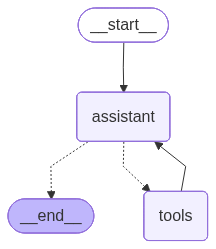

In [14]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("assistant", assistant_node)
    graph_builder.add_node("tools", ToolNode(TOOLS))

    graph_builder.add_edge(START, "assistant")
    graph_builder.add_conditional_edges("assistant", tools_condition)
    graph_builder.add_edge("tools", "assistant")

    return graph_builder.compile()

graph = build_graph()
graph


## 13. Visualize Mermaid graph


In [15]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	assistant(assistant)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> assistant;
	assistant -.-> __end__;
	assistant -.-> tools;
	tools --> assistant;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 14. Visualize PNG graph


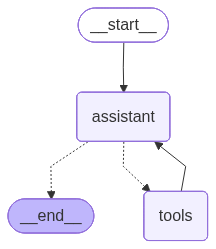

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 15. Run iterative SQL analysis

The LLM should decide whether it needs multiple SQL calls.


In [17]:
from langchain_core.messages import HumanMessage, SystemMessage

question = "Compare failed transactions before and after the latest release and identify the main failure reason."

result = graph.invoke(
    {
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=question),
        ]
    },
    {"recursion_limit": 10},
)

result["messages"][-1].content


'It appears that there are no failed transactions recorded both before and after the latest release (R13). Therefore, there are no failure reasons to identify.'

## 16. Inspect all messages

This shows the full ReAct-style loop.


In [18]:
for i, msg in enumerate(result["messages"], start=1):
    print("\n--- MESSAGE", i, type(msg).__name__, "---")
    print(msg.content)
    if getattr(msg, "tool_calls", None):
        print("TOOL CALLS:", msg.tool_calls)



--- MESSAGE 1 SystemMessage ---
You are an EPP SLA BI analyst.

You have access to a SQLite database with these tables:

epp_release(
  release_name TEXT,
  release_start TEXT,
  release_end TEXT,
  release_location TEXT
)

epp_sla(
  date TEXT,
  hour INTEGER,
  command TEXT,
  tld TEXT,
  response_time REAL,
  result TEXT,
  volume INTEGER,
  client_name TEXT,
  failed_reason TEXT
)

Rules:
- Use execute_sql for database questions.
- You may call execute_sql multiple times if needed.
- Prefer small targeted SQL queries.
- Only generate SELECT or WITH queries.
- Do not invent data.
- After enough SQL results are available, provide a concise final answer.
- When comparing before and after a release, first identify the relevant release window.


--- MESSAGE 2 HumanMessage ---
Compare failed transactions before and after the latest release and identify the main failure reason.

--- MESSAGE 3 AIMessage ---

TOOL CALLS: [{'name': 'execute_sql', 'args': {'query': 'SELECT * FROM epp_release

## 17. Try a simpler SQL question

Some questions may only require one SQL call.


In [19]:
simple_result = graph.invoke(
    {
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content="Which failed_reason has the highest total failure volume?"),
        ]
    },
    {"recursion_limit": 10},
)

simple_result["messages"][-1].content


'The failed reason with the highest total failure volume is **CONNECTION_TIMEOUT**, with a total failure volume of **555**.'

## 18. Why this is better than fixed-loop v8

Fixed-loop workflow:

```text
planner → sql_agent → evaluator → loop
```

Agentic SQL tool workflow:

```text
assistant → execute_sql → assistant → execute_sql → assistant
```

The LLM decides the next query based on actual SQL results.

This is the better foundation for:
- BI agents
- Text-to-SQL agents
- root-cause analysis
- incident investigation
- CloudOps diagnosis


## 19. Check LangSmith traces

Open LangSmith project:

```text
langgraph-playground
```

Look for:

- assistant node
- ChatOpenAI calls
- execute_sql tool calls
- generated SQL
- SQL results
- final answer

This trace is highly useful for debugging BI agents.
